# Task 1: Potential problems in linear regression

This notebook contains investigations of 3 potential problems of fitting linear models, sourced from section 3.3.3 in the EDS233 course textbook: [An Introduction to Statistical Learning with applications in Python](https://www.statlearning.com/). The section covers six common issues when fitting a linear model, and here I have selected **correlation of error terms**, **high-leverage points**, and **outliers**.

Additionally, in order to investigate these issues further, I used Claude to write Python code that:

- generates synthetic data that clearly illustrates the issue
- produces plots making the issue visually clear
- where applicable, produces additional plots showing how the issue can be addressed.

In [3]:
# Load necessary libraries
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

## Issue 1: Correlation of error terms

### Explanation

The standard errors of regression coefficients are calculated under the assumption that error terms are uncorrelated. However, when they *are* correlated but not accounted for, they produce standard errors that understimate the true standard error. This creates an unwarrated sense of confidence in the model (for example, it narrows the confidence interval). This issue can often occur in time series data, where observations that are proximate to one another in time may have similar errors, making them correlated. A way to detect this is to plot residuals against time – if the residuals show a pattern where observations next to each other tend to be all positive or all negative, that may be a sign of correlated error terms.

#### Question
One aspect that the text did not clarify for me is how to actually address the issue of correlation of error terms. From my investigations, I found that adding a time-lagged dependent variable can help reduce the effects of correlation, because it then models how past observations influence the current one. I think it is also important to simply be aware of potential correlation between error terms, and address it in interpretations of the model.

### Plots

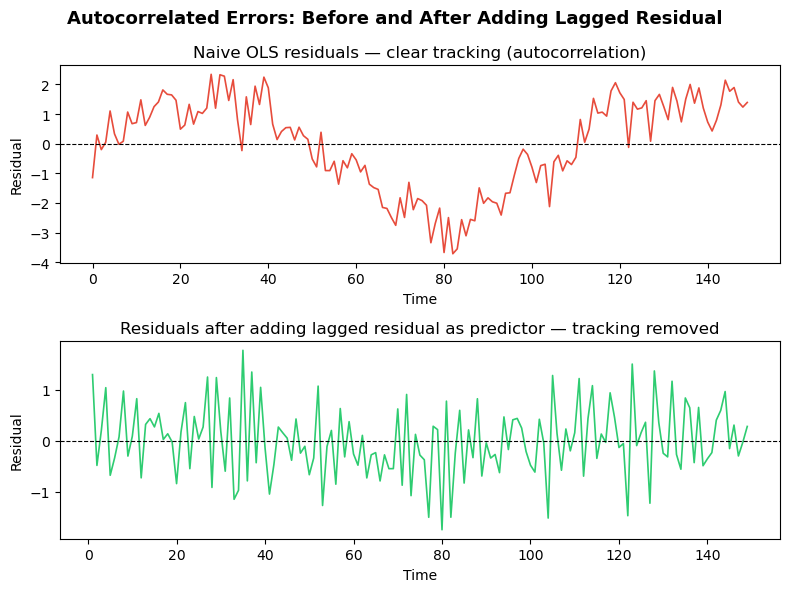

In [5]:
# Set random seed
np.random.seed(0)
n = 150
t = np.arange(n)

##  Generate synthetic data
# A slow-moving confound (e.g. temperature, economic cycle) that we don't observe
hidden = np.cumsum(np.random.normal(0, 0.3, n))  # random walk

# Observed predictor
x = t / 10 + np.random.normal(0, 0.5, n)

# y depends on x AND the hidden trend → errors will be autocorrelated
y = 2 * x + 0.8 * hidden + np.random.normal(0, 0.5, n)

# ── Naive OLS (ignores the hidden trend) ─────────────────────────────────────
slope, intercept, *_ = stats.linregress(x, y)
resid = y - (intercept + slope * x)

# ── Fix: add lagged residual as a proxy for the hidden trend ─────────────────
lag = 1
x_lag = resid[:-lag]          # lagged residual
x_cur = x[lag:]
y_cur = y[lag:]

X = np.column_stack([x_cur, x_lag])
coef, *_ = np.linalg.lstsq(np.column_stack([np.ones(len(y_cur)), X]), y_cur, rcond=None)
resid_fixed = y_cur - (coef[0] + coef[1] * x_cur + coef[2] * x_lag)

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 6), sharex=False)
fig.suptitle("Autocorrelated Errors: Before and After Adding Lagged Residual",
             fontsize=13, fontweight="bold")

ax1.plot(t, resid, color="#e74c3c", linewidth=1.2)
ax1.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax1.set_title("Naive OLS residuals — clear tracking (autocorrelation)")
ax1.set_xlabel("Time")
ax1.set_ylabel("Residual")

ax2.plot(t[lag:], resid_fixed, color="#2ecc71", linewidth=1.2)
ax2.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax2.set_title("Residuals after adding lagged residual as predictor — tracking removed")
ax2.set_xlabel("Time")
ax2.set_ylabel("Residual")

plt.tight_layout()

## Issue 2: Outliers

### Explanation

An outlier is a point for which the true response variable *y* is far from the model's predicted response. Keeping or removing the outlier can change the models relationship between predictors and the response variable, but even when the slope doesn't change, outliers can negatively impact metrics such as RSE and R-squared. Therefore, outliers can alter model interpretation and accuracy if not addressed. 

Outliers can be detected by plotting residuals and seeing if there are any that are much greater than the others. However, this leads to the issue of determining what is actually "much greater". A way to decide this is by plotting the *studentized* residuals instead, which are equal to the residual divided by its estimated standard error. Once located, the issue of outliers can be addressed by simple removal if it is determined to be due to a collection error. However, it is also important to consider if maybe the outlier is a sign of a missing predictor.

#### Question

The text only discusses two reasons for outliers: a missing predictor or collection error. Are there other ways they can come about? Some answers I found fall into these two categories, but are more specific:

Collection errors
- Errors from data entry
- Errors from measurement (tools were not properly calibrated or were not operating correctly)
- Contamination of sample, where observations from different populations were included

Model errors
- Applying a linear model to data that is non-linear can make data points on the edge appear as outliers

True outliers
- Rare natural occurences during data collection could lead to genuinely extreme values

### Plots

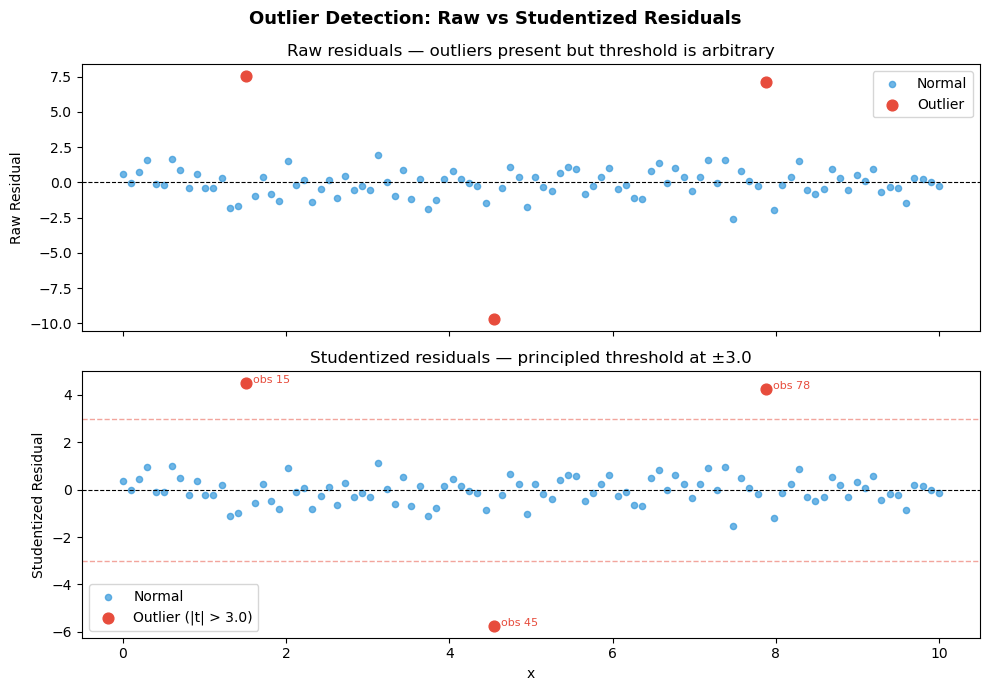

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

np.random.seed(42)
n = 100
x = np.linspace(0, 10, n)
y = 2 * x + 1 + np.random.normal(0, 1, n)

# Inject a few outliers (unusual y values)
outlier_idx = [15, 45, 78]
y[outlier_idx] += [8, -9, 7]

# Fit OLS
slope, intercept, *_ = stats.linregress(x, y)
y_hat = intercept + slope * x
resid = y - y_hat

# Studentized residuals: resid / (s * sqrt(1 - h_ii))
# h_ii = leverage = 1/n + (x_i - x_bar)^2 / sum((x - x_bar)^2)
x_bar = x.mean()
ss_x = np.sum((x - x_bar) ** 2)
leverage = 1 / n + (x - x_bar) ** 2 / ss_x

p = 2  # intercept + slope
mse = np.sum(resid**2) / (n - p)
studentized = resid / np.sqrt(mse * (1 - leverage))

threshold = 3.0
is_outlier = np.abs(studentized) > threshold

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 7), sharex=True)
fig.suptitle("Outlier Detection: Raw vs Studentized Residuals", fontsize=13, fontweight="bold")

normal = ~is_outlier

ax1.scatter(x[normal], resid[normal], color="#3498db", s=20, alpha=0.7, label="Normal")
ax1.scatter(x[is_outlier], resid[is_outlier], color="#e74c3c", s=60, zorder=5, label="Outlier")
ax1.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax1.set_ylabel("Raw Residual")
ax1.set_title("Raw residuals — outliers present but threshold is arbitrary")
ax1.legend()

ax2.scatter(x[normal], studentized[normal], color="#3498db", s=20, alpha=0.7, label="Normal")
ax2.scatter(x[is_outlier], studentized[is_outlier], color="#e74c3c", s=60, zorder=5, label=f"Outlier (|t| > {threshold})")
ax2.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax2.axhline(threshold, color="#e74c3c", linewidth=1, linestyle="--", alpha=0.5)
ax2.axhline(-threshold, color="#e74c3c", linewidth=1, linestyle="--", alpha=0.5)
ax2.set_ylabel("Studentized Residual")
ax2.set_xlabel("x")
ax2.set_title(f"Studentized residuals — principled threshold at ±{threshold}")
ax2.legend()

for idx in outlier_idx:
    ax2.annotate(f"  obs {idx}", (x[idx], studentized[idx]), fontsize=8, color="#e74c3c")

plt.tight_layout()

### Question

## Issue 3

### Explanation

### Plots

In [ ]:
code

### Question

## Generative AI reflection